In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

In [4]:
depths = [1, 3, 5, None]
tree_models = {}

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train_2d, y_train)
    tree_models[depth] = clf
    
    print(f"Depth={depth}")
    print("Train Accuracy:", accuracy_score(y_train, clf.predict(X_train_2d)))
    print("Test Accuracy:", accuracy_score(y_test, clf.predict(X_test_2d)))
    print()

Depth=1
Train Accuracy: 0.9274725274725275
Test Accuracy: 0.8771929824561403

Depth=3
Train Accuracy: 0.9516483516483516
Test Accuracy: 0.9210526315789473

Depth=5
Train Accuracy: 0.9846153846153847
Test Accuracy: 0.956140350877193

Depth=None
Train Accuracy: 1.0
Test Accuracy: 0.9385964912280702



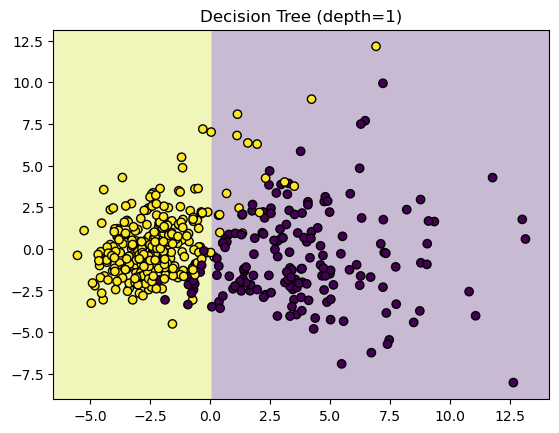

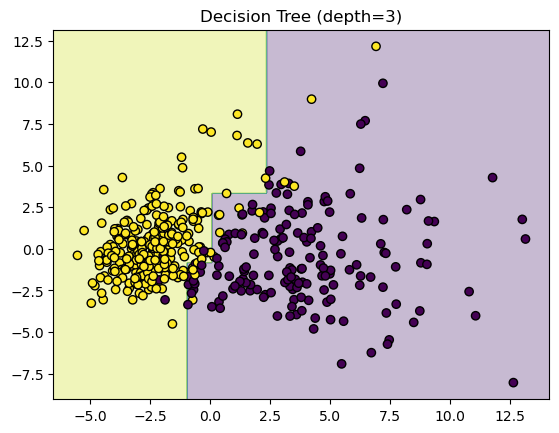

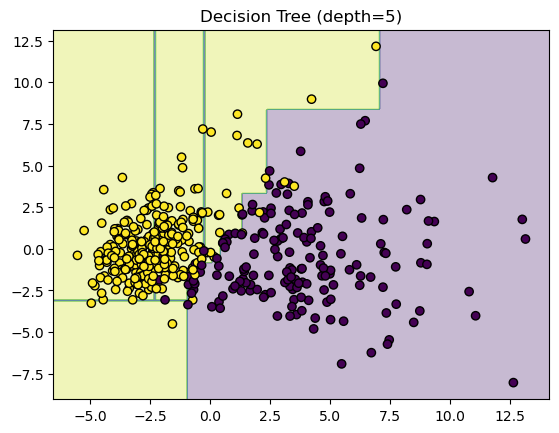

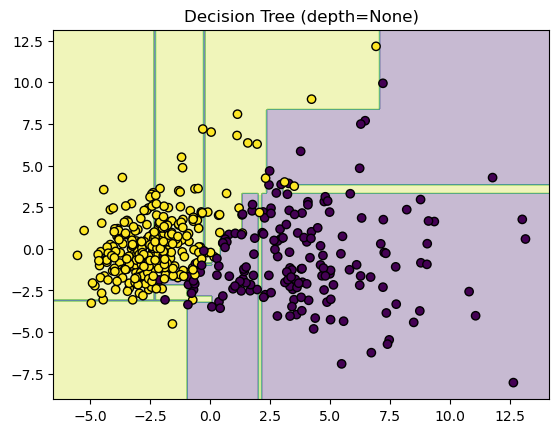

In [5]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.show()


for depth, model in tree_models.items():
    plot_decision_boundary(model, X_train_2d, y_train, f"Decision Tree (depth={depth})")

In [6]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500))
    ]),
    "SVM (Linear)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear"))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf"))
    ]),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

In [7]:
for name, model in models.items():
    print(f"\n{name}")
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_weighted")
    print("CV F1-score:", cv_scores.mean())
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    
    results[name] = cv_scores.mean()

print("\nModel Comparison (CV F1-score):")
for model, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model}: {score:.4f}")


Logistic Regression
CV F1-score: 0.9779723127493465
Test Accuracy: 0.9824561403508771
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
 [[41  1]
 [ 1 71]]

SVM (Linear)
CV F1-score: 0.9647419514163836
Test Accuracy: 0.9736842105263158
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[41  1]
 [ 2 70]]

SVM (RBF)
CV F1-score: 0.9691328298607977
Test Accurac

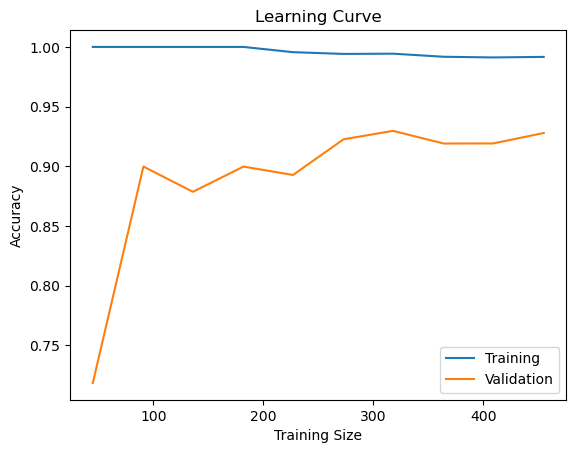

In [8]:
train_sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=5),
    X, y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
plt.legend()
plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.show()

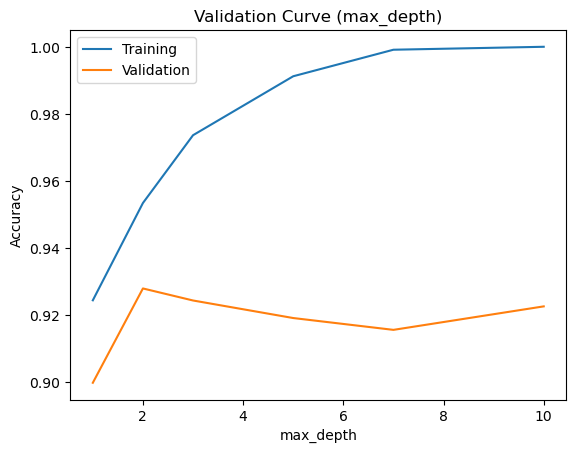

In [9]:
param_range = [1, 2, 3, 5, 7, 10]

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(),
    X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

plt.plot(param_range, train_scores.mean(axis=1), label="Training")
plt.plot(param_range, val_scores.mean(axis=1), label="Validation")
plt.legend()
plt.title("Validation Curve (max_depth)")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.show()


In [10]:
print("Cross-Validation Variability:")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Cross-Validation Variability:
Logistic Regression: Mean=0.9807, Std=0.0146
SVM (Linear): Mean=0.9754, Std=0.0196
SVM (RBF): Mean=0.9753, Std=0.0252
Decision Tree: Mean=0.9104, Std=0.0297
Random Forest: Mean=0.9632, Std=0.0355
Gradient Boosting: Mean=0.9614, Std=0.0291
